# **YOLO Model Comparison**

# **1. Importing Dependencies**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# **2. CSV File Loading**

In [2]:
df5  = pd.read_csv("/kaggle/input/model-1/5_validation_results.csv", index_col=0)
df10 = pd.read_csv("/kaggle/input/model-1/10_validation_results.csv", index_col=0)
df15 = pd.read_csv("/kaggle/input/model-1/15_validation_results.csv", index_col=0)
df20 = pd.read_csv("/kaggle/input/model-1/20_validation_results.csv", index_col=0)
df40 = pd.read_csv("/kaggle/input/40-epoch/validation_results (3).csv", index_col=0)
dfc50 = pd.read_csv("/kaggle/input/40custom/validation_results (4).csv", index_col=0)
dfyc50 = pd.read_csv("/kaggle/input/50-custom/custom_validation_results.csv", index_col=0)
dfyc150 = pd.read_csv("/kaggle/input/150epoch/validation_results.csv", index_col=0)


dfhypcu50 = pd.read_csv("/kaggle/input/hypertuned/50hypcu_validation_results.csv",index_col=0)
dfhypcu100 = pd.read_csv("/kaggle/input/hypertuned/100hypcu_validation_results.csv",index_col=0)
dfhypcu150 = pd.read_csv("/kaggle/input/hypertuned/150hypcu_validation_results.csv",index_col=0)
dfhypcu200 = pd.read_csv("/kaggle/input/hypertuned/200hypcu_validation_results.csv",index_col=0)
df100iter = pd.read_csv("/kaggle/input/100iter/100iter_validation_results.csv",index_col=0)
dfcustom_c0 = pd.read_csv("/kaggle/input/custom-c0/custom_c0_hypcu_validation_results.csv", index_col=0)
bd100 = pd.read_csv("/kaggle/input/datasets/sarveshvengurlekar1/bdd100/bdd_validation_results.csv", index_col=0)
bd100k = pd.read_csv("/kaggle/input/datasets/sarveshvengurlekar1/bdd320/bdd_5_epoch_validation_results.csv",index_col=0)
bd100k_15epoch = pd.read_csv("/kaggle/input/datasets/sarveshvengurlekar1/bdd-15-epoch-csv/bdd_15_epoch_validation_results.csv",index_col=0)

df50cu2 = pd.read_csv("/kaggle/input/datasets/sarveshvengurlekar1/custom-dataset-model-val-v2/50_validation_results.csv",index_col=0)
df100cu2 = pd.read_csv("/kaggle/input/datasets/sarveshvengurlekar1/custom-dataset-model-val-v2/100_validation_results.csv",index_col=0)
df150cu2 = pd.read_csv("/kaggle/input/datasets/sarveshvengurlekar1/custom-dataset-model-val-v2/150_validation_results.csv",index_col=0)
df200cu2 = pd.read_csv("/kaggle/input/datasets/sarveshvengurlekar1/custom-dataset-model-val-v2/200_validation_results.csv",index_col=0)


# **3. Metrics Comparison**

          50 Epoch  100 Epoch  150 Epoch  200 Epoch
Box-P     0.656476   0.669191   0.650204   0.708792
Box-R     0.615566   0.652623   0.656329   0.626806
Box-F1    0.613187   0.651331   0.647642   0.645612
mAP50     0.631082   0.667978   0.655687   0.651544
mAP50-95  0.458772   0.500131   0.493094   0.490224


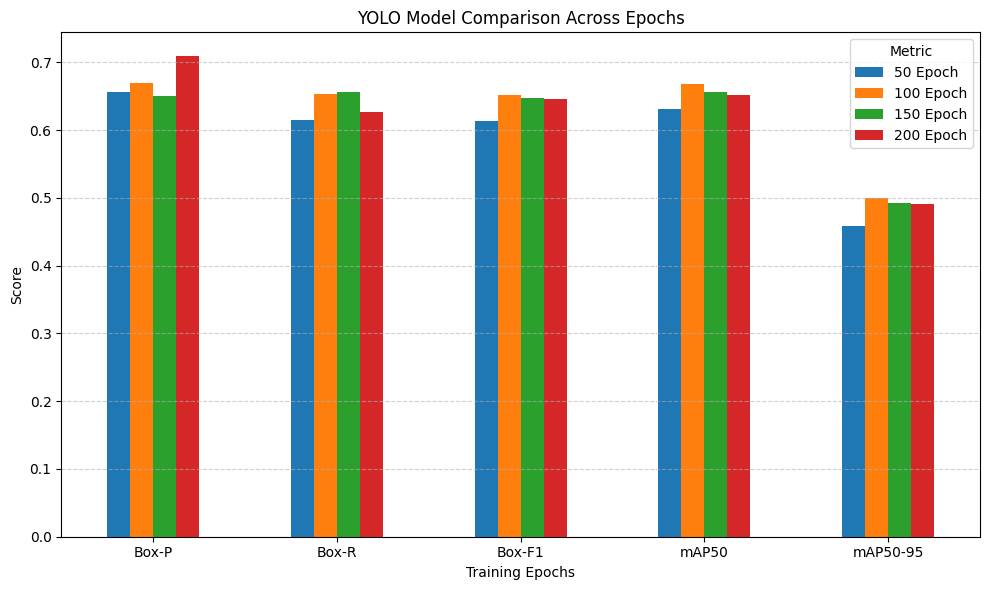

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Box-P","Box-R","Box-F1","mAP50", "mAP50-95"]

# Compute mean metrics
summary_df = pd.DataFrame({

    "50 Epoch":  [df50cu2[m].mean() for m in metrics],
    "100 Epoch":  [df100cu2[m].mean() for m in metrics],
    "150 Epoch":  [df150cu2[m].mean() for m in metrics],
    "200 Epoch":  [df200cu2[m].mean() for m in metrics],
       
}, index=metrics)

print(summary_df)

# Plot
summary_df.plot(kind="bar", figsize=(10, 6))

plt.title("YOLO Model Comparison Across Epochs")
plt.xlabel("Training Epochs")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


# **4. Classwise Comparsion**

In [4]:
print("df50cu2 classes:", df50cu2.index.tolist())
print("df100cu2 classes:", df100cu2.index.tolist())
print("df150cu2 classes:", df150cu2.index.tolist())
print("df200cu2 classes:", df200cu2.index.tolist())

classes = df200cu2.index.tolist()

df50cu2 classes: ['bridge', 'building', 'bus', 'car', 'motorcycle', 'person', 'rickshaw', 'road barrier', 'road sign board', 'street light', 'traffic signal', 'trees', 'truck', 'zebra crossing']
df100cu2 classes: ['bridge', 'building', 'bus', 'car', 'motorcycle', 'person', 'rickshaw', 'road barrier', 'road sign board', 'street light', 'traffic signal', 'trees', 'truck', 'zebra crossing']
df150cu2 classes: ['bridge', 'building', 'bus', 'car', 'motorcycle', 'person', 'rickshaw', 'road barrier', 'road sign board', 'street light', 'traffic signal', 'trees', 'truck', 'zebra crossing']
df200cu2 classes: ['bridge', 'building', 'bus', 'car', 'motorcycle', 'person', 'rickshaw', 'road barrier', 'road sign board', 'street light', 'traffic signal', 'trees', 'truck', 'zebra crossing']


In [5]:
classes = df200cu2.index.tolist()
x = np.arange(len(classes))
print(classes)

['bridge', 'building', 'bus', 'car', 'motorcycle', 'person', 'rickshaw', 'road barrier', 'road sign board', 'street light', 'traffic signal', 'trees', 'truck', 'zebra crossing']


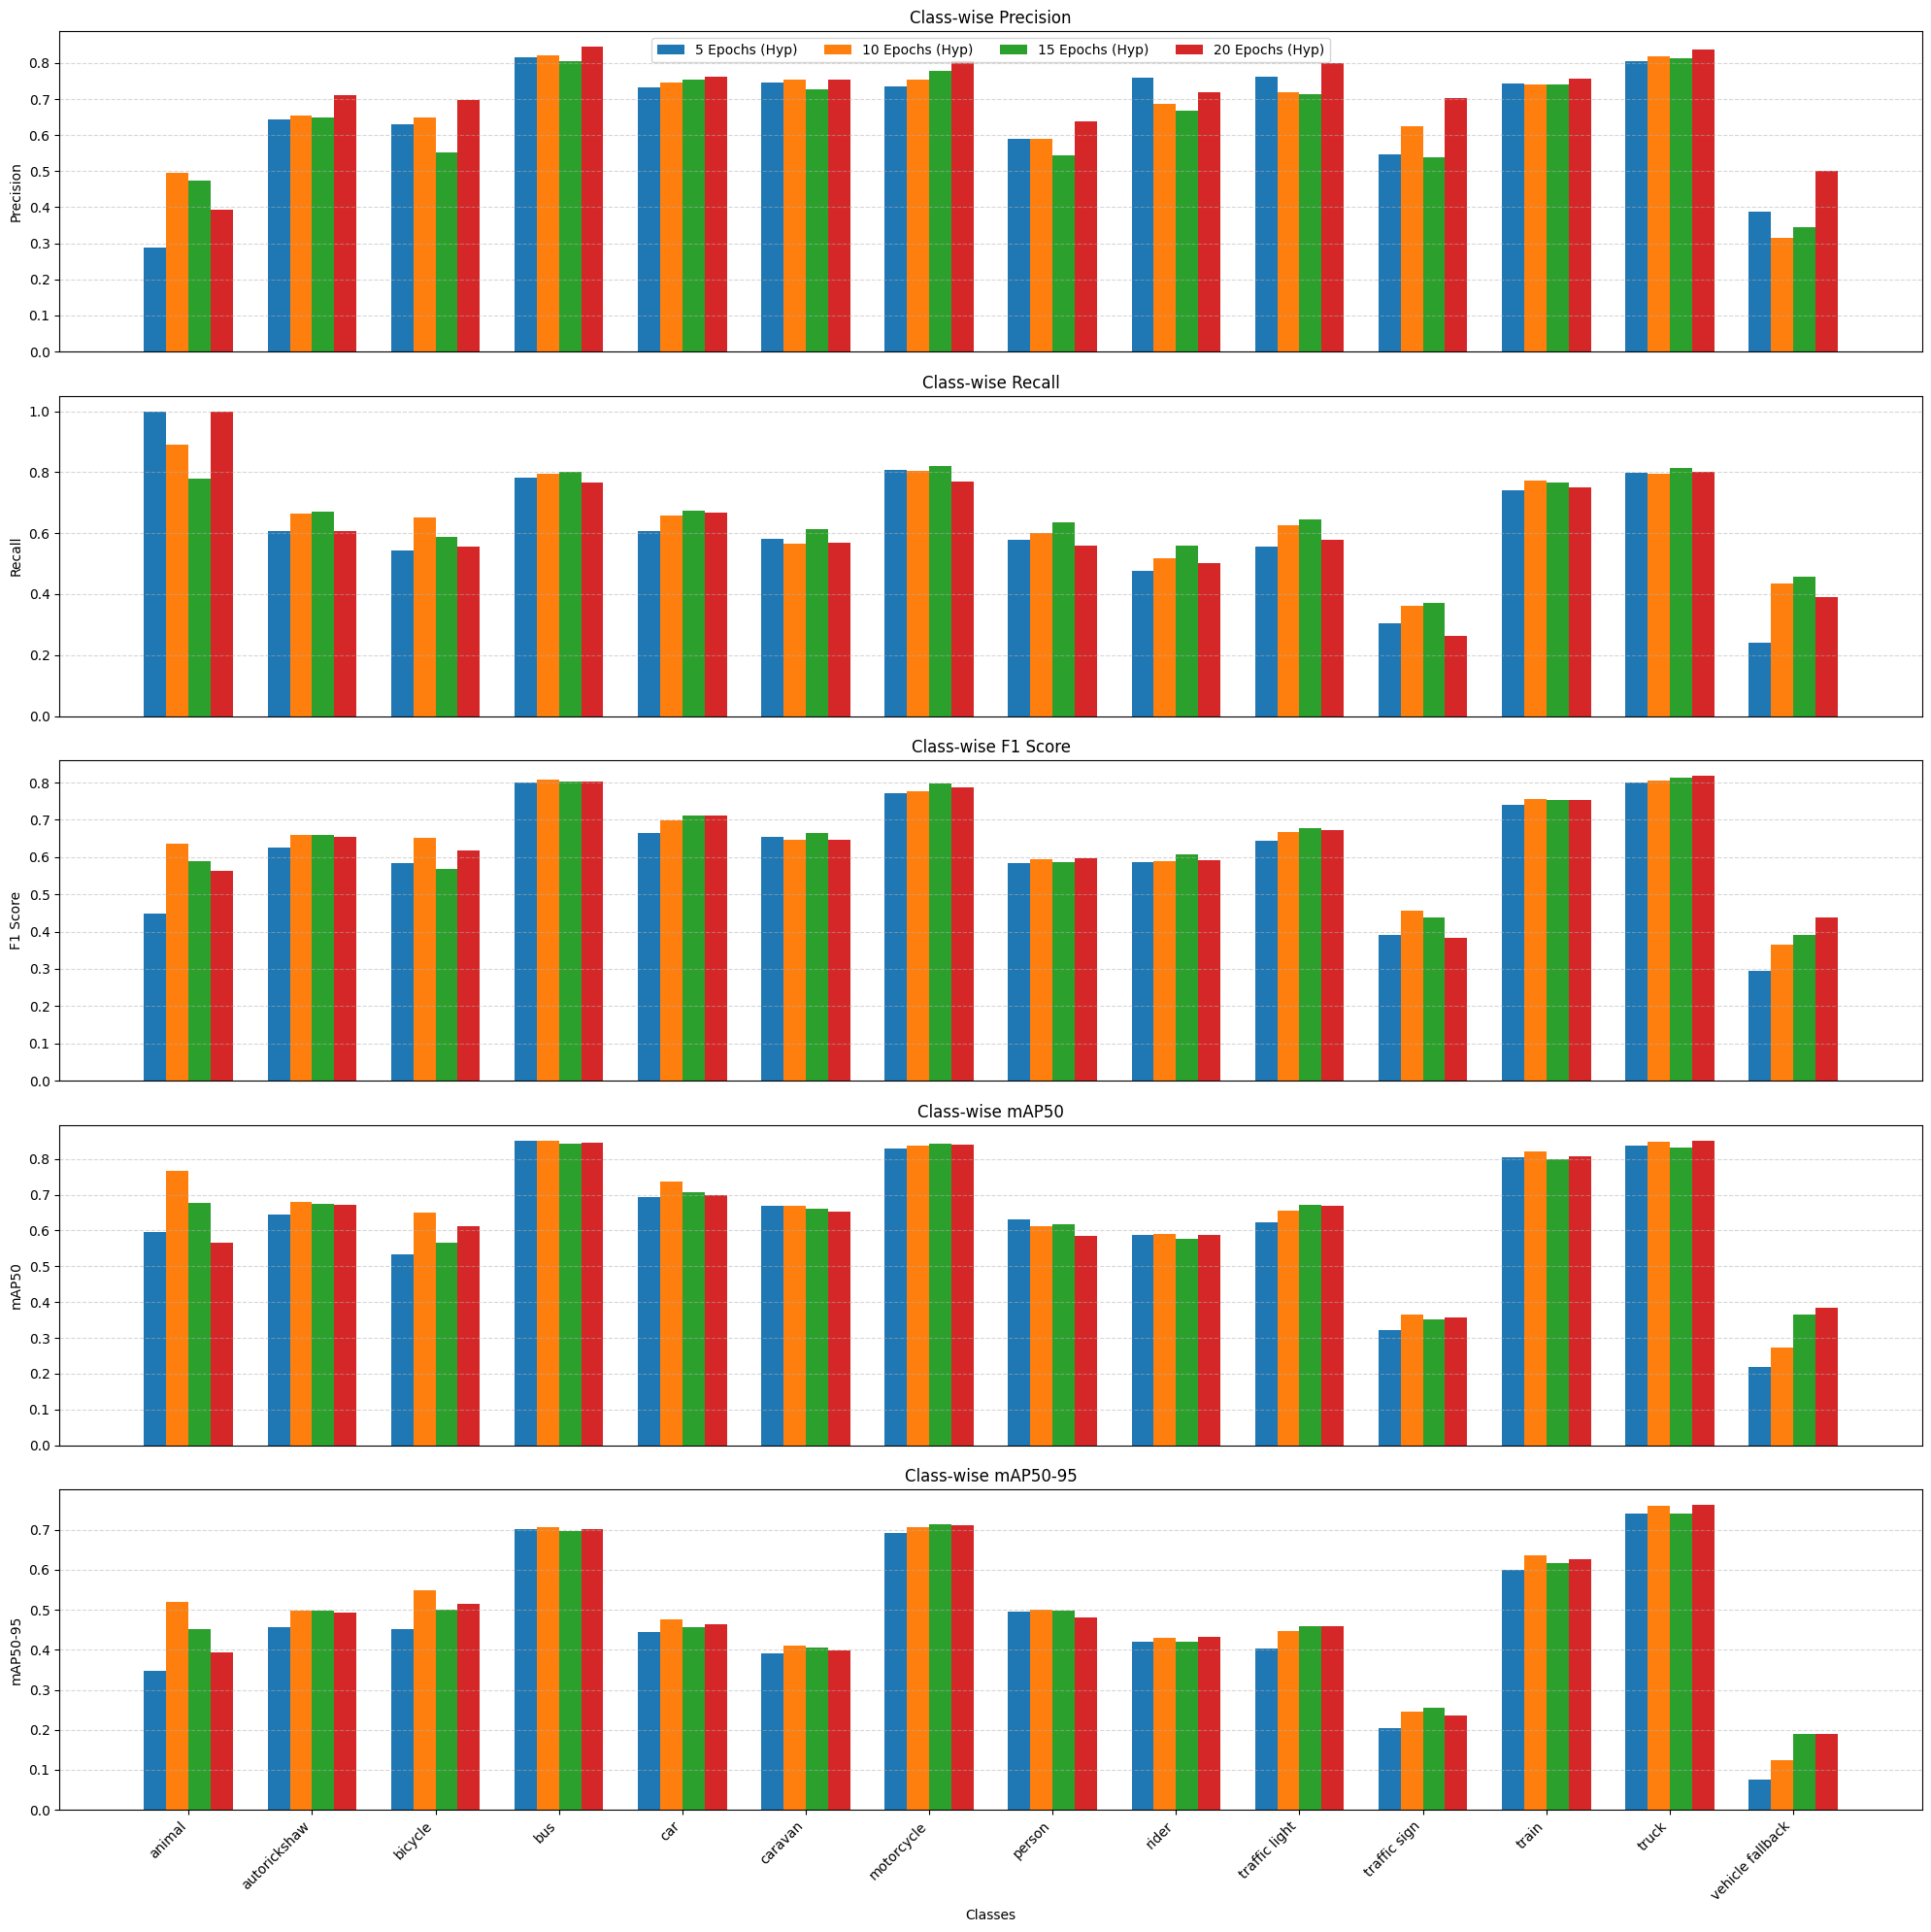

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Class appending & serialization 
classes = df5.index.tolist()
x = np.arange(len(classes))
w = 0.18

plt.figure(figsize=(20, 20))

# Subplot 1: Box-P
plt.subplot(5, 1, 1)
plt.bar(x + 0*w, df50cu2["Box-P"],  w, label="5 Epochs (Hyp)")
plt.bar(x + 1*w, df100cu2["Box-P"], w, label="10 Epochs (Hyp)")
plt.bar(x + 2*w, df150cu2["Box-P"], w, label="15 Epochs (Hyp)")
plt.bar(x + 3*w, df200cu2["Box-P"], w, label="20 Epochs (Hyp)")

plt.title("Class-wise Precision")
plt.ylabel("Precision")
plt.legend(ncol=4)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# Subplot 2: Box-R
plt.subplot(5, 1, 2)
plt.bar(x + 0*w, df50cu2["Box-R"],  w)
plt.bar(x + 1*w, df100cu2["Box-R"], w)
plt.bar(x + 2*w, df150cu2["Box-R"], w)
plt.bar(x + 3*w, df200cu2["Box-R"], w)

plt.title("Class-wise Recall")
plt.ylabel("Recall")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# Subplot 3: Box-F1
plt.subplot(5, 1, 3)
plt.bar(x + 0*w, df50cu2["Box-F1"],  w)
plt.bar(x + 1*w, df100cu2["Box-F1"], w)
plt.bar(x + 2*w, df150cu2["Box-F1"], w)
plt.bar(x + 3*w, df200cu2["Box-F1"], w)

plt.title("Class-wise F1 Score")
plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# Subplot 4: mAP50
plt.subplot(5, 1, 4)
plt.bar(x + 0*w, df50cu2["mAP50"],  w)
plt.bar(x + 1*w, df100cu2["mAP50"], w)
plt.bar(x + 2*w, df150cu2["mAP50"], w)
plt.bar(x + 3*w, df200cu2["mAP50"], w)

plt.title("Class-wise mAP50")
plt.ylabel("mAP50")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# Subplot 5: mAP50-95
plt.subplot(5, 1, 5)
plt.bar(x + 0*w, df50cu2["mAP50-95"],  w)
plt.bar(x + 1*w, df100cu2["mAP50-95"], w)
plt.bar(x + 2*w, df150cu2["mAP50-95"], w)
plt.bar(x + 3*w, df200cu2["mAP50-95"], w)

plt.title("Class-wise mAP50-95")
plt.ylabel("mAP50-95")
plt.xticks(x + 1.5*w, classes, rotation=45, ha="right")
plt.xlabel("Classes")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# **Real Code**

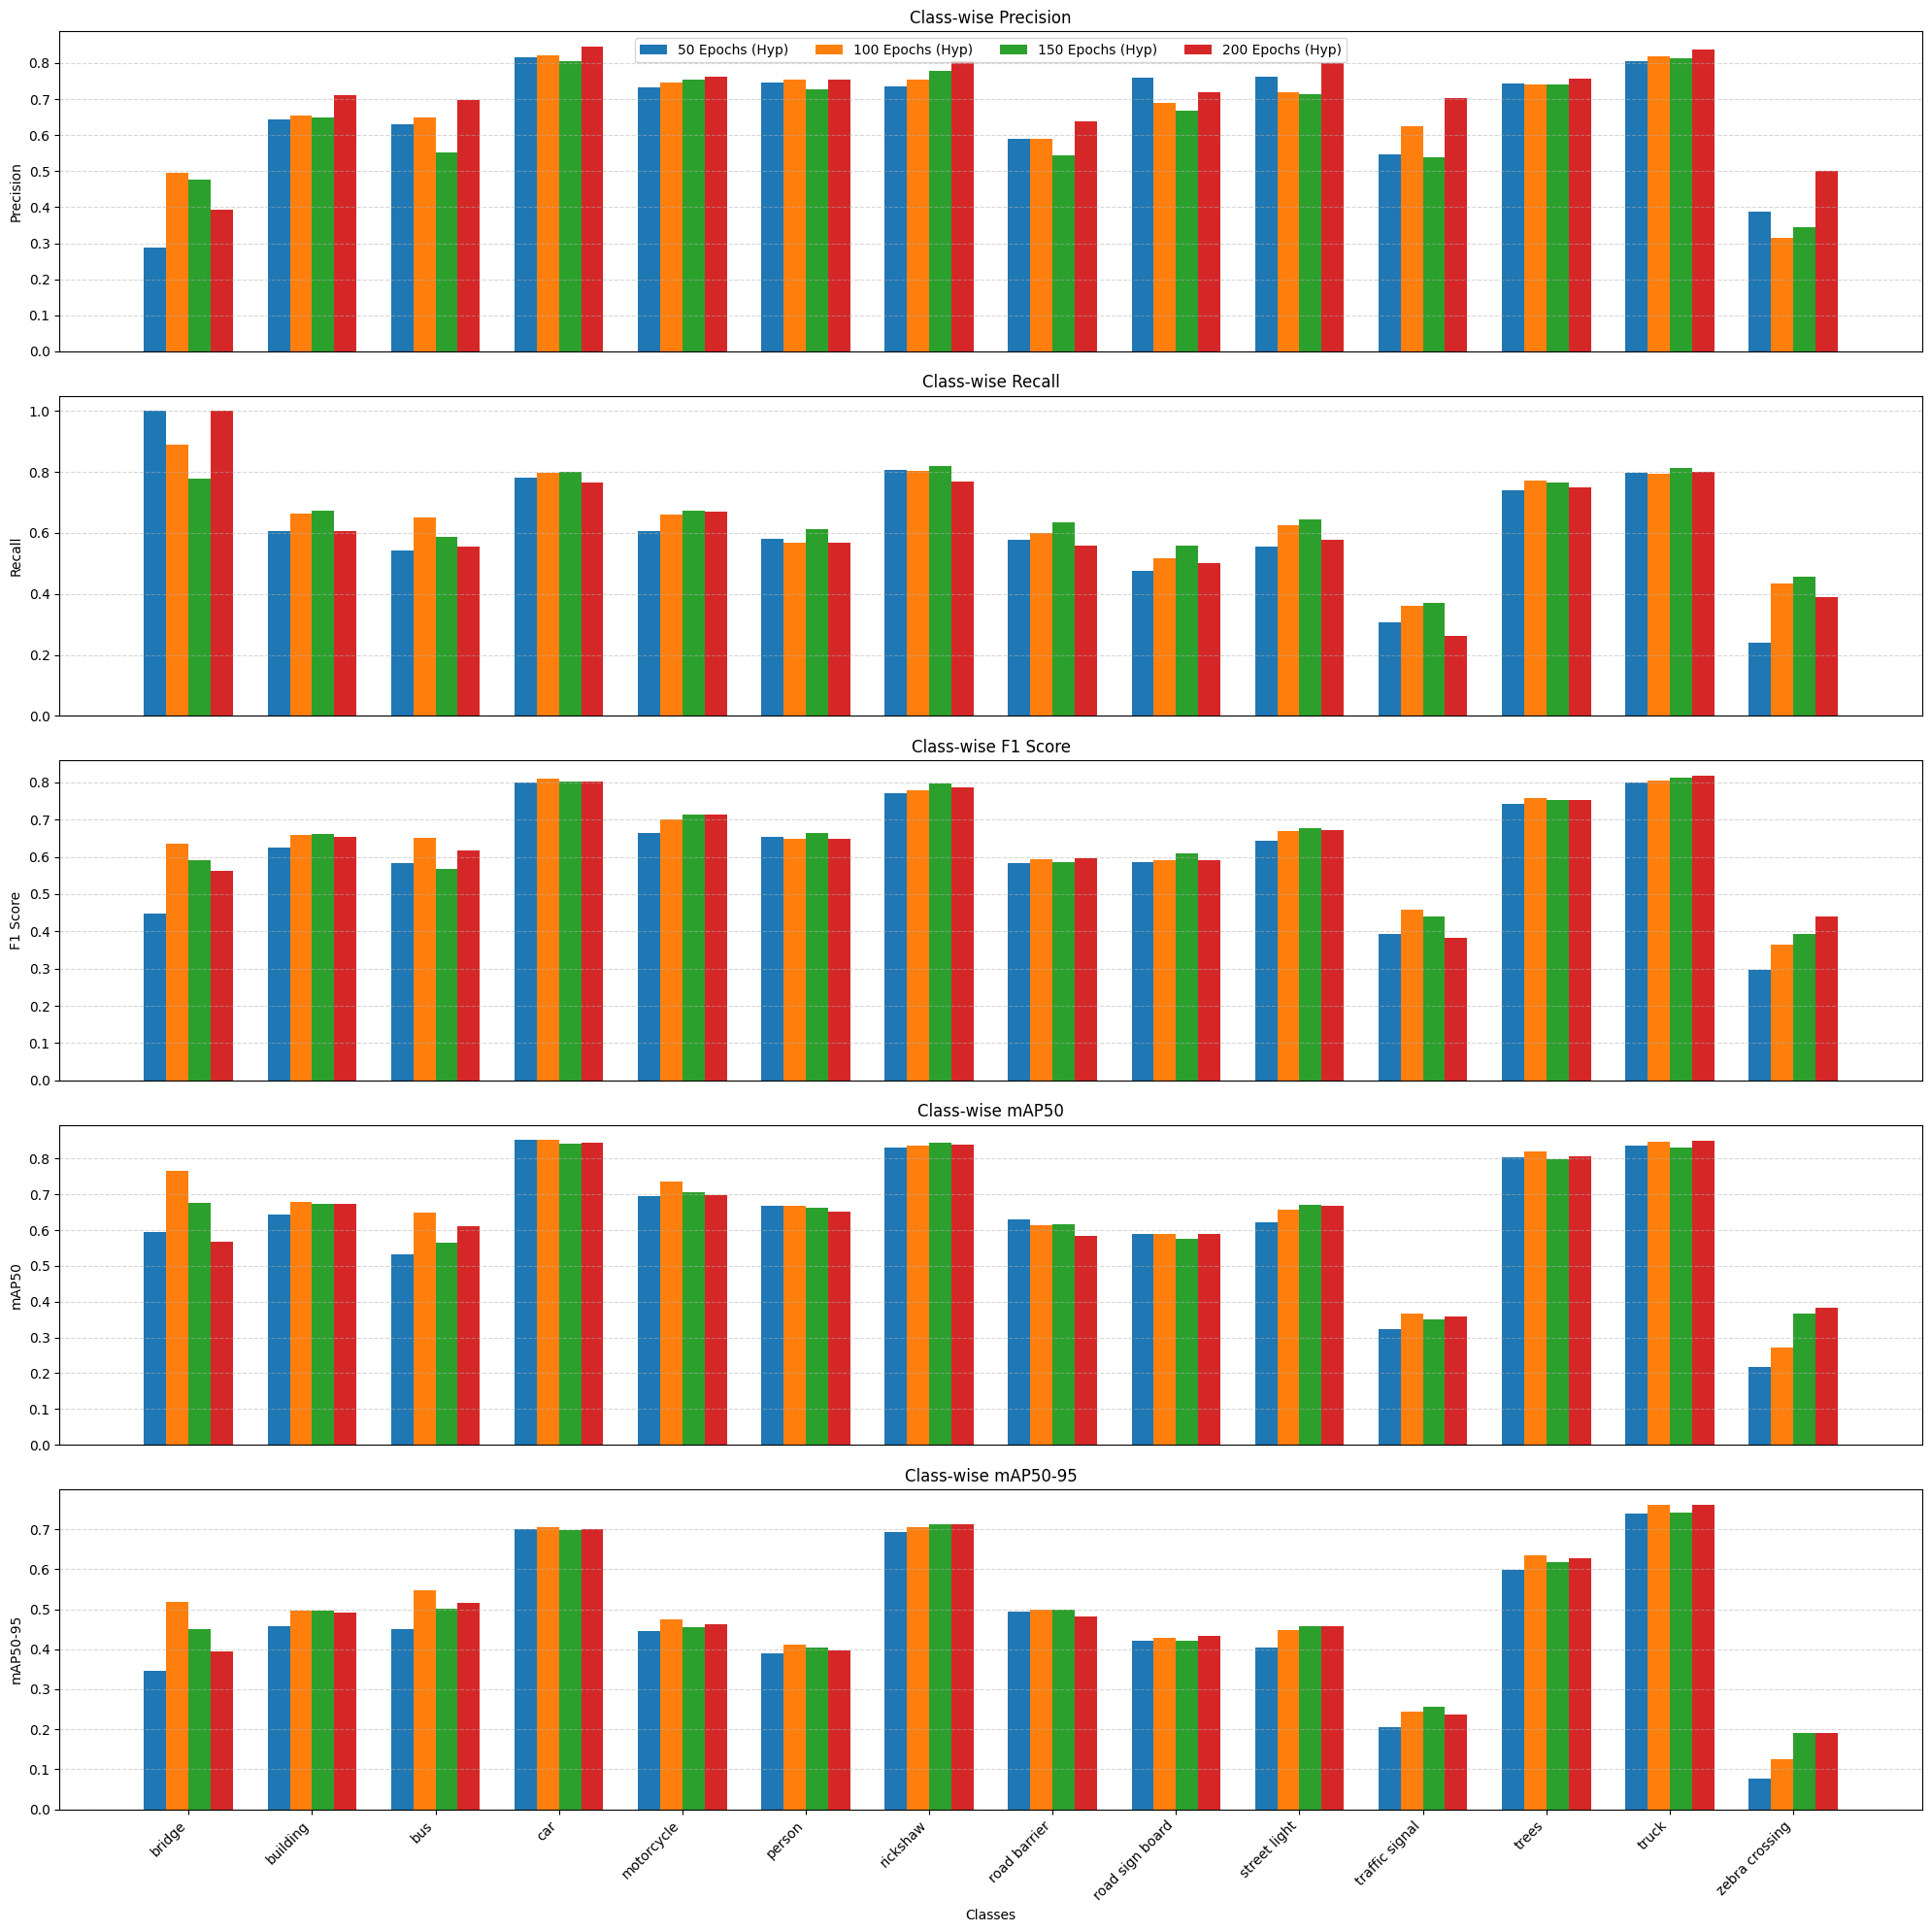

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Always close previous figures (avoids old plot confusion)
plt.close('all')

# -----------------------------
# 1️⃣ Ensure All DataFrames Are Aligned
# -----------------------------

# Take classes from one dataframe (reference)
common_classes = df50cu2.index

# Force all dataframes to use SAME class order
df100cu2 = df100cu2.loc[common_classes]
df150cu2 = df150cu2.loc[common_classes]
df200cu2 = df200cu2.loc[common_classes]

# Convert to list
classes = common_classes.tolist()

# X-axis positions
x = np.arange(len(classes))
w = 0.18  # bar width

# -----------------------------
# 2️⃣ Create Figure
# -----------------------------
plt.figure(figsize=(20, 20))

# -----------------------------
# Subplot 1: Precision
# -----------------------------
plt.subplot(5, 1, 1)
plt.bar(x + 0*w, df50cu2["Box-P"],  w, label="50 Epochs (Hyp)")
plt.bar(x + 1*w, df100cu2["Box-P"], w, label="100 Epochs (Hyp)")
plt.bar(x + 2*w, df150cu2["Box-P"], w, label="150 Epochs (Hyp)")
plt.bar(x + 3*w, df200cu2["Box-P"], w, label="200 Epochs (Hyp)")

plt.title("Class-wise Precision")
plt.ylabel("Precision")
plt.legend(ncol=4)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 2: Recall
# -----------------------------
plt.subplot(5, 1, 2)
plt.bar(x + 0*w, df50cu2["Box-R"],  w)
plt.bar(x + 1*w, df100cu2["Box-R"], w)
plt.bar(x + 2*w, df150cu2["Box-R"], w)
plt.bar(x + 3*w, df200cu2["Box-R"], w)

plt.title("Class-wise Recall")
plt.ylabel("Recall")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 3: F1 Score
# -----------------------------
plt.subplot(5, 1, 3)
plt.bar(x + 0*w, df50cu2["Box-F1"],  w)
plt.bar(x + 1*w, df100cu2["Box-F1"], w)
plt.bar(x + 2*w, df150cu2["Box-F1"], w)
plt.bar(x + 3*w, df200cu2["Box-F1"], w)

plt.title("Class-wise F1 Score")
plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 4: mAP50
# -----------------------------
plt.subplot(5, 1, 4)
plt.bar(x + 0*w, df50cu2["mAP50"],  w)
plt.bar(x + 1*w, df100cu2["mAP50"], w)
plt.bar(x + 2*w, df150cu2["mAP50"], w)
plt.bar(x + 3*w, df200cu2["mAP50"], w)

plt.title("Class-wise mAP50")
plt.ylabel("mAP50")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 5: mAP50-95
# -----------------------------
plt.subplot(5, 1, 5)
plt.bar(x + 0*w, df50cu2["mAP50-95"],  w)
plt.bar(x + 1*w, df100cu2["mAP50-95"], w)
plt.bar(x + 2*w, df150cu2["mAP50-95"], w)
plt.bar(x + 3*w, df200cu2["mAP50-95"], w)

plt.title("Class-wise mAP50-95")
plt.ylabel("mAP50-95")
plt.xticks(x + 1.5*w, classes, rotation=45, ha="right")
plt.xlabel("Classes")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

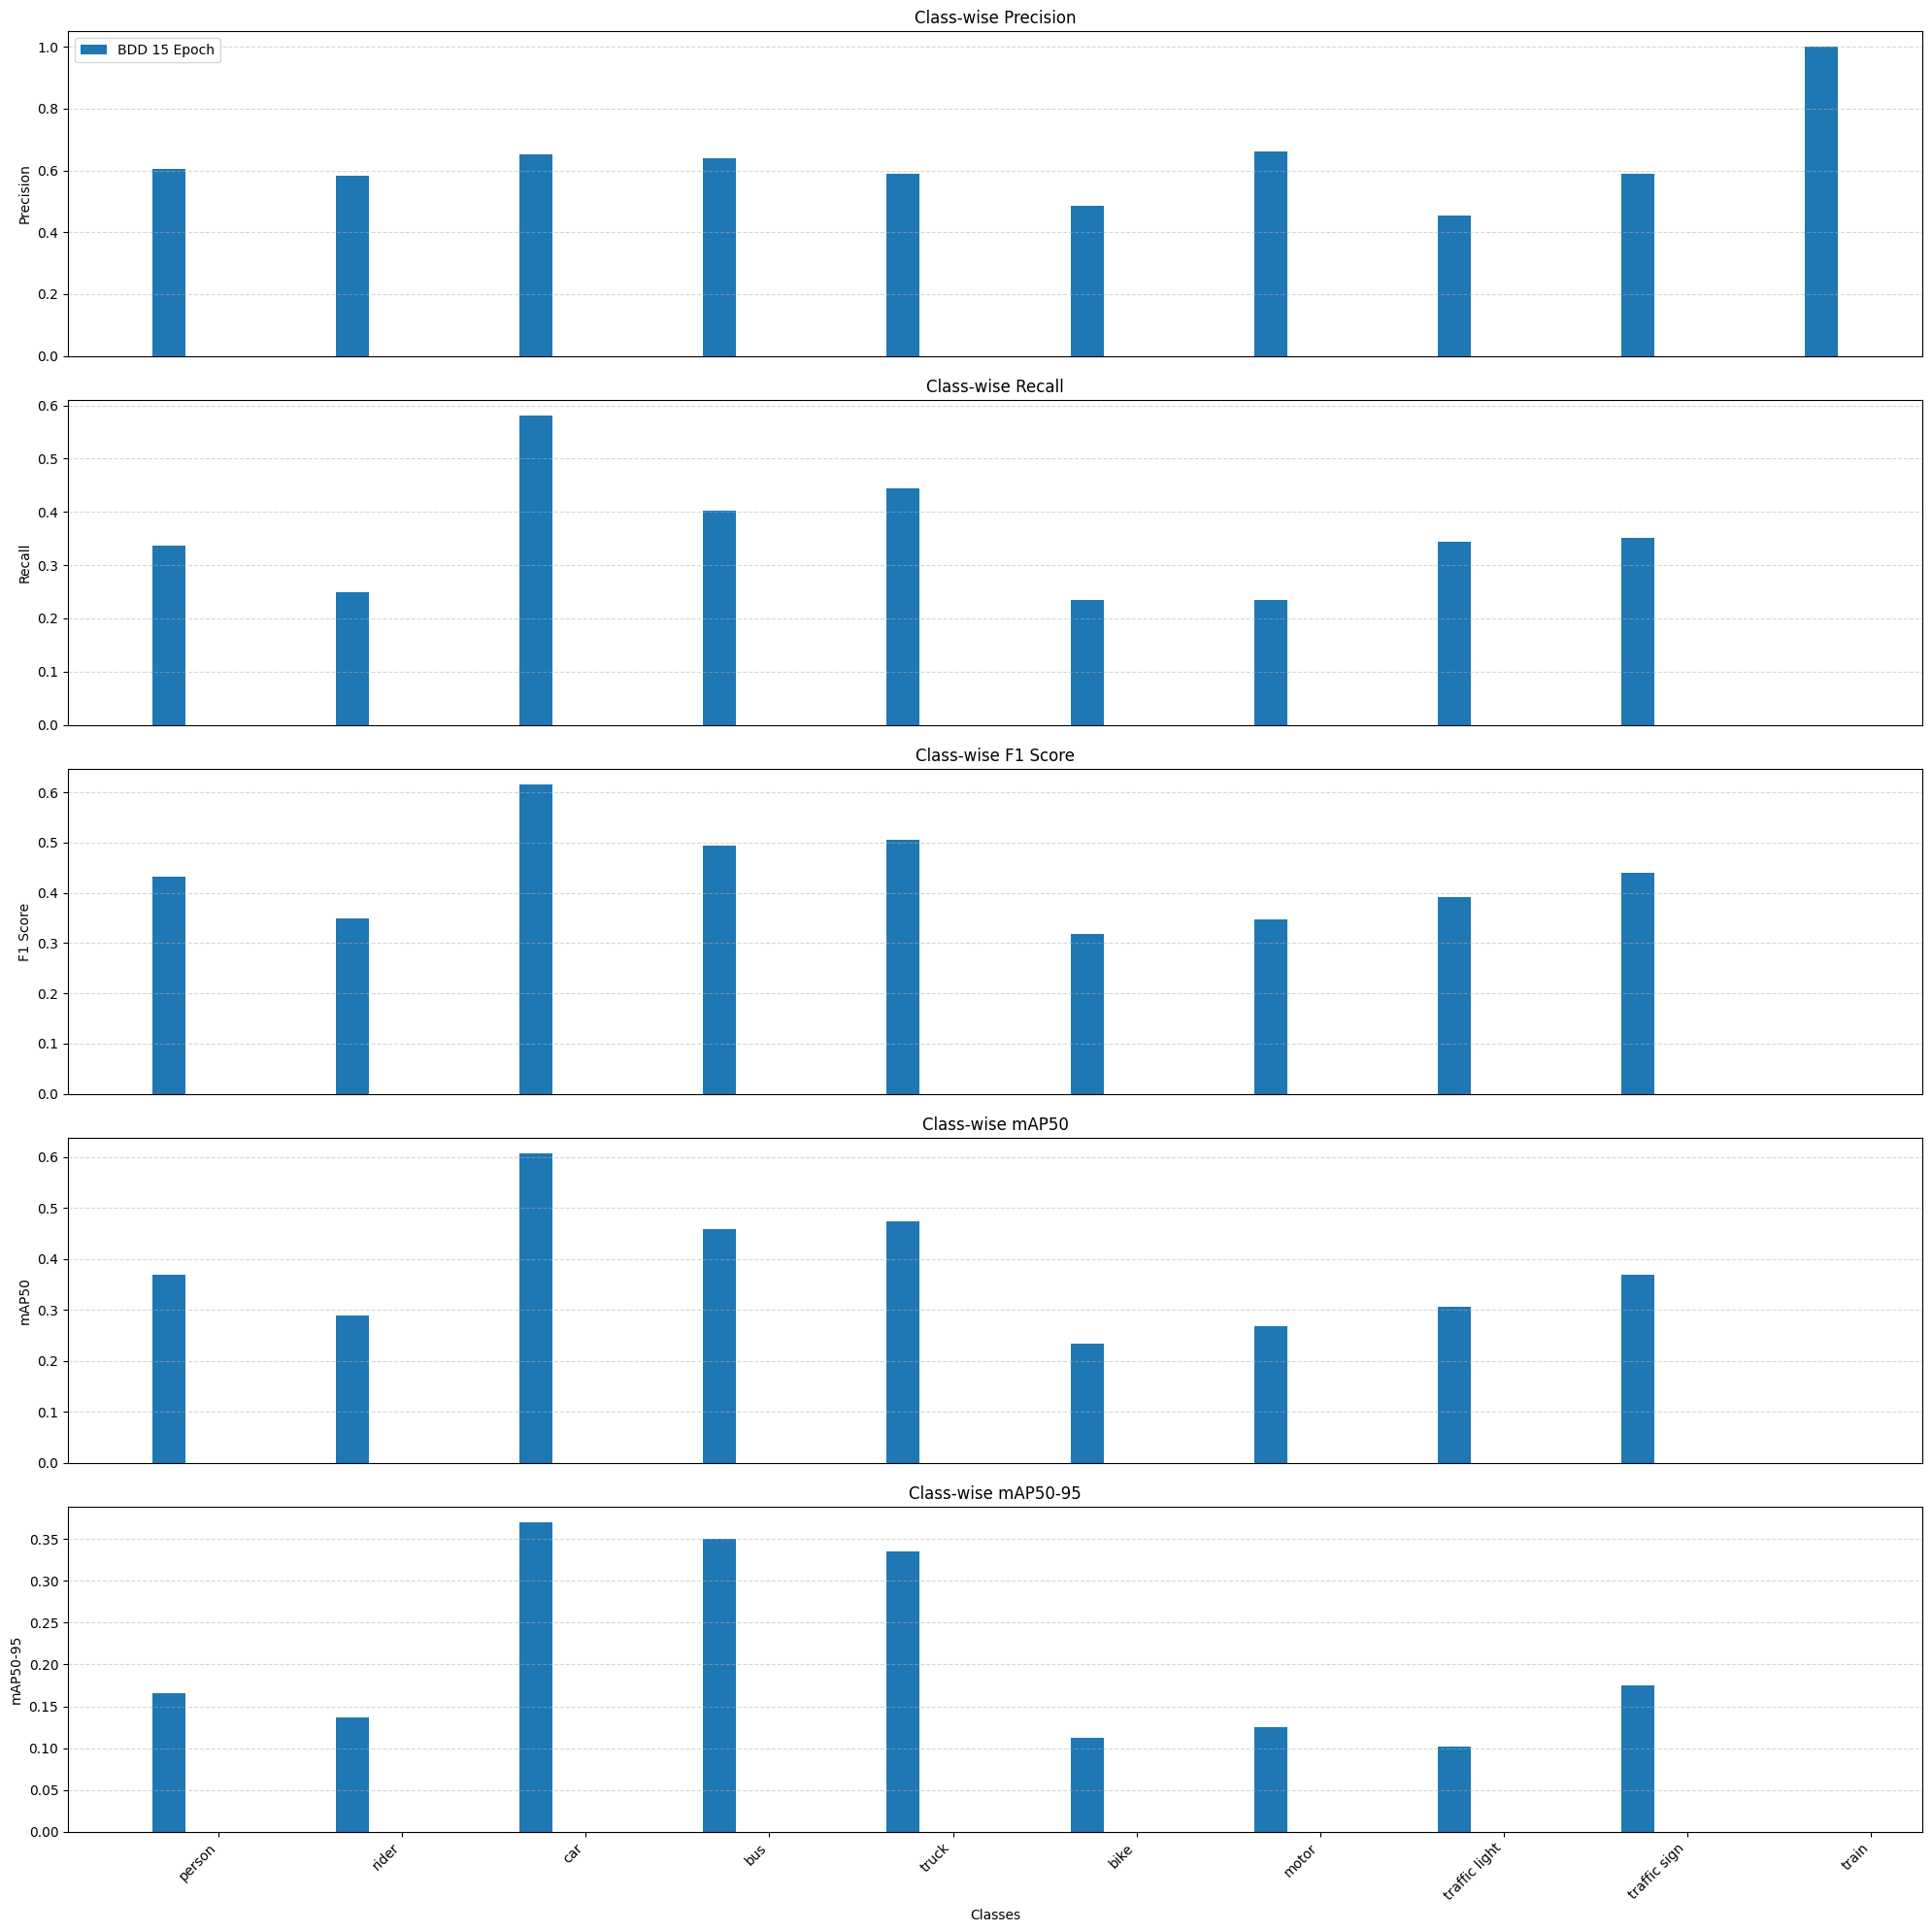

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Always close previous figures (avoids old plot confusion)
plt.close('all')

# -----------------------------
# 1️⃣ Ensure All DataFrames Are Aligned
# -----------------------------

# Take classes from one dataframe (reference)
common_classes = bd100k_15epoch.index

# # Force all dataframes to use SAME class order
# df100cu2 = df100cu2.loc[common_classes]
# df150cu2 = df150cu2.loc[common_classes]
# df200cu2 = df200cu2.loc[common_classes]

# Convert to list
classes = common_classes.tolist()

# X-axis positions
x = np.arange(len(classes))
w = 0.18  # bar width

# -----------------------------
# 2️⃣ Create Figure
# -----------------------------
plt.figure(figsize=(20, 20))

# -----------------------------
# Subplot 1: Precision
# -----------------------------
plt.subplot(5, 1, 1)
plt.bar(x + 0*w, bd100k_15epoch["Box-P"],  w, label="BDD 15 Epoch")

plt.title("Class-wise Precision")
plt.ylabel("Precision")
plt.legend(ncol=4)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 2: Recall
# -----------------------------
plt.subplot(5, 1, 2)
plt.bar(x + 0*w, bd100k_15epoch["Box-R"],  w)
# plt.bar(x + 1*w, df100cu2["Box-R"], w)
# plt.bar(x + 2*w, df150cu2["Box-R"], w)
# plt.bar(x + 3*w, df200cu2["Box-R"], w)

plt.title("Class-wise Recall")
plt.ylabel("Recall")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 3: F1 Score
# -----------------------------
plt.subplot(5, 1, 3)
plt.bar(x + 0*w, bd100k_15epoch["Box-F1"],  w)
# plt.bar(x + 1*w, df100cu2["Box-F1"], w)
# plt.bar(x + 2*w, df150cu2["Box-F1"], w)
# plt.bar(x + 3*w, df200cu2["Box-F1"], w)

plt.title("Class-wise F1 Score")
plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 4: mAP50
# -----------------------------
plt.subplot(5, 1, 4)
plt.bar(x + 0*w, bd100k_15epoch["mAP50"],  w)
# plt.bar(x + 1*w, df100cu2["mAP50"], w)
# plt.bar(x + 2*w, df150cu2["mAP50"], w)
# plt.bar(x + 3*w, df200cu2["mAP50"], w)

plt.title("Class-wise mAP50")
plt.ylabel("mAP50")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks([])

# -----------------------------
# Subplot 5: mAP50-95
# -----------------------------
plt.subplot(5, 1, 5)
plt.bar(x + 0*w, bd100k_15epoch["mAP50-95"],  w)
# plt.bar(x + 1*w, df100cu2["mAP50-95"], w)
# plt.bar(x + 2*w, df150cu2["mAP50-95"], w)
# plt.bar(x + 3*w, df200cu2["mAP50-95"], w)

plt.title("Class-wise mAP50-95")
plt.ylabel("mAP50-95")
plt.xticks(x + 1.5*w, classes, rotation=45, ha="right")
plt.xlabel("Classes")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()